In [2]:
import pandas as pd
import numpy as np
from scipy.stats import skewnorm
from apriori import apriori
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import voronoi_plot_2d
import random

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
datas = pd.read_csv('PSCompPars_2025.06.12_09.54.16.csv', comment='#', low_memory=False)
data = pd.DataFrame(data=datas)
origdata = data.copy(deep = True)
#These two were labeled incorrectly on the dataframe
data.replace({ 'st_spectype': {'m3 V':'M V'} }, inplace = True)
data.replace({ 'st_spectype': {'sdBV':'B V'} }, inplace = True)

In [4]:
#assigns random temperature for each planet
def rand_temp(row):
    try:
        mean = row['pl_eqt'] + ((row['pl_eqterr1']+row['pl_eqterr2'])/2)
        sd = row['pl_eqt'] + row['pl_eqterr1'] - mean
        a = (3*(mean-row['pl_eqt']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_eqterr1'], size=1)[0]
    except:
        return row['pl_eqt']

#assigns random planet radius:  
def rand_prade(row):
    try:
        mean = row['pl_rade'] + ((row['pl_radeerr1']+row['pl_radeerr2'])/2)
        sd = row['pl_rade'] + row['pl_radeerr1'] - mean
        a = (3*(mean-row['pl_rade']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_radeerr1'], size=1)[0]
    except:
        return row['pl_rade']

#assigns random planet semimajor axis: 
def rand_majoraxis(row):
    try:
        mean = row['pl_orbsmax'] + ((row['pl_orbsmaxerr1']+row['pl_orbsmaxerr2'])/2)
        sd = row['pl_orbsmax'] + row['pl_orbsmaxerr1'] - mean
        a = (3*(mean-row['pl_orbsmax']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbsmaxerr1'], size=1)[0]
    except: 
        return row['pl_orbsmax']

#assigns random planet orbital period:
def rand_orbper(row):
    try:
        mean = row['pl_orbper'] + ((row['pl_orbpererr1']+row['pl_orbpererr2'])/2)
        sd = row['pl_orbper'] + row['pl_orbpererr1'] - mean
        a = (3*(mean-row['pl_orbper']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbpererr1'], size=1)[0]
    except: 
        return row['pl_orbper']

#estimates the semimajor axis given a row of a data frame given stellar mass and orbital period: Kepler's 3rd law
#Only estimates the semimajor axis if the value is originally NaN
def estimate_orbsmax(row):
    if pd.isna(row['pl_orbsmax']):
        try: 
            return (((6.67e-11 * (row['st_mass'] * 1.989e30) * ((row['pl_orbper'] * 86400)**2)) / (4 * (np.pi**2)))**(1/3)) / 1.496e11
        except:
            return np.nan
    else:
        return row['pl_orbsmax']
        

#Sets the spectral type if it is already in the string for the spectype variable for each row.
#Otherwise, it is estimated based on equillibrium temperature.
def get_spectype(row):
    try: 
        return row['st_spectype'][0]
    except:
        if(row['st_teff']>=30000):
            return 'O'
        elif(row['st_teff']>=10000):
            return 'B'
        elif(row['st_teff']>=7500):
            return 'A'
        elif(row['st_teff']>=6000):
            return 'F'
        elif(row['st_teff']>=5200):
            return 'G'
        elif(row['st_teff']>=3700):
            return 'K'
        elif(row['st_teff']>=2400):
            return 'M'
        else:
            return row['st_spectype']

#Estimates the equillibrium temperature of a row given stellar luminosity, and semimajor axis
#Only estimates if there is a missing value for pl_eqt: Stefan-Boltzmann's law
def estimate_pl_eqt(row):
    if pd.isna(row['pl_eqt']):
        try:
            return (((10 ** row['st_lum']) * 3.827e26) / (16 * np.pi * 5.67e-8 * ((row['pl_orbsmax'] * 1.496e11) ** 2))) ** (1 / 4)
        except:
            return np.nan
    else:
        return row['pl_eqt']


#Grabs the last value of the string, usually the Luminosity Class of the star
#Otherwise, estimates whethoer or not the star is main sequence based on the luminosity of the star
def is_mainsequence(row):
    if(str(row['st_spectype'])[-1] == ('V') and str(row['st_spectype'])[-2:] != ('IV')):
        return 'True'
    else:
        try:
            if(str(row['spectype']).__contains__('M') and row['st_lum'] < -1.0969):
                return 'True'
            elif(str(row['spectype']).__contains__('K') and row['st_lum'] < -0.2218):
                return 'True'
            elif(str(row['spectype']).__contains__('G') and row['st_lum'] < 0.1761):
                return 'True'
            elif(str(row['spectype']).__contains__('F') and row['st_lum'] < 0.699):
                return 'True'
            elif(str(row['spectype']).__contains__('A') and row['st_lum'] < 1.3979):
                return 'True'
            elif(str(row['spectype']).__contains__('B') and row['st_lum'] < 4.477):
                return 'True'
            elif(str(row['spectype']).__contains__('O')):
                return 'True'
            else:
                return 'False'
        except:
            return 'False'   

#Gets the right hand and left hand side of the rule and puts it in an items list
pl_pattern = re.compile(r'(.+?)(\d)')
def parse_rule(rule_str):
    lhs, rhs = rule_str.split('->')
    lhs_items = [item.strip() for item in lhs.strip('{} ').split(',')]
    rhs = rhs.split("{")[1].split("}")[0]
    rhs_items = [item.strip() for item in rhs.strip('{} ').split(',')]
    return lhs_items, rhs_items

#Puts items in a system into a dictionary so that they are easy to compare, get counts for classifications
def get_plnum_dict(items):
    orbital_dict = {}
    for item in items:
        match = pl_pattern.match(item)
        if match:
            base_type, number = match.groups()
            number = int(number)
            orbital_dict.setdefault(base_type, set()).add(number)
    return orbital_dict

#This is only for if you include the bins in the rule (at bottom)
def get_plnum(items):
    mydict = {}
    for i in items:
        number = int(i[-1])
        string = i[:-1]
        if not string in mydict:
            mydict[string] = []
        mydict[string].append(number)
    return mydict

In [5]:
data = origdata.copy(deep= True)
#applying all of the non-random variables
data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
data['spectype'] = data.apply(get_spectype, axis = 1)
data['isMS'] = data.apply(is_mainsequence, axis = 1)
#Remove systems with more that one host star
star = data.loc[data['sy_snum'] < 2]
# Excluded planet systems that did not have any data on the variables of interest
star = star.loc[star['pl_orbper'].isna() == False]
star = star.loc[star['pl_rade'].isna() == False]
star = star.loc[star['st_teff'].isna() == False]
star = star.loc[star['pl_eqt'].isna() == False]
star = star.loc[star['spectype'].isna() == False]
star = star.loc[star['st_met'].isna() == False]
star = star.loc[star['st_met'] > 0]
star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
#Creating a dataframe with only main sequence stars and their proper classificaiton
onlyMS = star.loc[star['isMS'] == 'True']

#originally 12 only MS and pl class
'''test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname'], 'metallicity': onlyMS['st_met'], 'mass': onlyMS['st_mass']}'''

#originally 49 only MS and pl+star class
test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname'], 'metallicity': onlyMS['st_met'], 'mass': onlyMS['st_mass']}

#originally 70 all stars and pl class
'''test = {'type': star['pl_class'],'host':star['hostname'], 'metallicity': star['st_met'], 'mass': star['st_mass']}'''

#Originally 103 all stars and pl+st class
'''test = {'type': star['stars_class'],'host':star['hostname']}'''

testing = pd.DataFrame(data=test)
repeats = testing.groupby('host')

modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    metaladded = False
    for idx, row in group.iterrows():
        if not metaladded and ('metallicity' in row):
            new_types.append(row['metallicity'])
            metaladded = True
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(list(new_types))
print(len(modified_tuples))
print(modified_tuples)

1538
[[0.4052, 'K Cold Gas Giant Long Orbital1', 'K Cold Gas Giant Long Orbital2'], [0.04, 'G Temperate Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital2'], [0.18, 'G Hot Gas Giant Short Orbital1'], [0.19, 'F Hot Gas Giant Long Orbital1'], [0.17, 'K Temperate Gas Giant Medium-Long Orbital1'], [0.18, 'K Temperate Gas Giant Medium-Long Orbital1'], [0.38, 'K Hot Gas Giant Short Orbital1'], [0.12, 'K Cold Gas Giant Long Orbital1', 'K Cold Gas Giant Long Orbital2'], [0.13, 'M Warm Mini-Neptune Short Orbital1'], [0.26, 'K Warm Gas Giant Medium-Short Orbital1'], [0.16, 'G Hot Gas Giant Short Orbital1'], [0.01, 'G Hot Gas Giant Short Orbital1'], [0.05, 'F Hot Gas Giant Short Orbital1'], [0.19, 'G Warm Gas Giant Short Orbital1'], [0.14, 'G Hot Gas Giant Short Orbital1', 'G Cold Gas Giant Long Orbital1'], [0.17, 'G Warm Sub-Saturn Short Orbital1'], [0.05, 'G Hot Gas Giant Short Orbital1'], [0.3, 'K Hot Mini-Neptune Short Orbital1', 'K Warm Sub-Saturn Med

# Generating rules through the binning process

In [ ]:
itemset, rules = apriori(transactions=modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5, bins = 10)

In [ ]:

print(len(rules))
rules

### Only use this one if the bins == 1

In [ ]:
filtered_rules = []
#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in rules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum_dict(lhs_items)
    rhs_plnum = get_plnum_dict(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum_dict(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)
rules = filtered_rules.copy()

### Only use this one if bins>1

In [ ]:
for rang in rules:
    filtered_rules = []
    #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
    for rule in rules[rang]:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        lhs_plnum = get_plnum_dict(lhs_items)
        rhs_plnum = get_plnum_dict(rhs_items)
        all_items = lhs_items + rhs_items
        all_plnum = get_plnum_dict(all_items)
        rule_valid = True
        for base_type, plnums in lhs_plnum.items():
            for num in plnums:
                if num > 1:
                    required = set(range(1, num))
                    if not required.issubset(plnums):
                        rule_valid = False
                        break
            if not rule_valid:
                break
        for base_type, plnum in rhs_plnum.items():
            if not rule_valid:
                break
            for items in plnum:
                if items > 1:
                    required = set(range(1, items))
                    if not required.issubset(all_plnum[base_type]):
                        rule_valid = False
                        break
        if rule_valid:
            filtered_rules.append(rule)
        rules[rang] = filtered_rules

In [ ]:
print(rules)
summation = 0
for ran in rules:
    summation+=len(rules[ran])
print(summation)
print(rules.keys())

In [6]:
modified_tuples2 = []
for host2, group2 in repeats:
    seen = {}
    new_types = []
    metaladded = False
    for idx, row in group2.iterrows():
        if not metaladded and ('metallicity' in row):
            new_types.append(row['metallicity'])
            new_types.append(row['mass'])
            metaladded = True
    for t in group2['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples2.append(list(new_types))
print(len(modified_tuples2))
print(modified_tuples2)

1538
[[0.4052, 0.91, 'K Cold Gas Giant Long Orbital1', 'K Cold Gas Giant Long Orbital2'], [0.04, 1.06, 'G Temperate Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital2'], [0.18, 1.03, 'G Hot Gas Giant Short Orbital1'], [0.19, 1.2, 'F Hot Gas Giant Long Orbital1'], [0.17, 0.49, 'K Temperate Gas Giant Medium-Long Orbital1'], [0.18, 0.909, 'K Temperate Gas Giant Medium-Long Orbital1'], [0.38, 1.47, 'K Hot Gas Giant Short Orbital1'], [0.12, 0.679, 'K Cold Gas Giant Long Orbital1', 'K Cold Gas Giant Long Orbital2'], [0.13, 0.161, 'M Warm Mini-Neptune Short Orbital1'], [0.26, 0.89, 'K Warm Gas Giant Medium-Short Orbital1'], [0.16, 1.078, 'G Hot Gas Giant Short Orbital1'], [0.01, 1.09, 'G Hot Gas Giant Short Orbital1'], [0.05, 1.13, 'F Hot Gas Giant Short Orbital1'], [0.19, 1.098, 'G Warm Gas Giant Short Orbital1'], [0.14, 1.14, 'G Hot Gas Giant Short Orbital1', 'G Cold Gas Giant Long Orbital1'], [0.17, 1.099, 'G Warm Sub-Saturn Short Orbital1'], [0.05,

In [7]:
itemset, rules, vor, groups = apriori(transactions=modified_tuples2, min_support= 2/len(modified_tuples2), min_confidence=.5, bins = 10)

In [ ]:
for rang in rules:
    filtered_rules = []
    #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
    for rule in rules[rang]:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        lhs_plnum = get_plnum_dict(lhs_items)
        rhs_plnum = get_plnum_dict(rhs_items)
        all_items = lhs_items + rhs_items
        all_plnum = get_plnum_dict(all_items)
        rule_valid = True
        for base_type, plnums in lhs_plnum.items():
            for num in plnums:
                if num > 1:
                    required = set(range(1, num))
                    if not required.issubset(plnums):
                        rule_valid = False
                        break
            if not rule_valid:
                break
        for base_type, plnum in rhs_plnum.items():
            if not rule_valid:
                break
            for items in plnum:
                if items > 1:
                    required = set(range(1, items))
                    if not required.issubset(all_plnum[base_type]):
                        rule_valid = False
                        break
        if rule_valid:
            filtered_rules.append(rule)
        rules[rang] = filtered_rules

In [ ]:
summation = 0
listofnone = []
for rule in rules:
    summation += len(rules[rule])
    if len(rules[rule]) > 0:
        print(str(rule), 'total: ', len(rules[rule]))
        print(str(rule) + ': ' + str(rules[rule]))
print(str('composite total: '), summation)

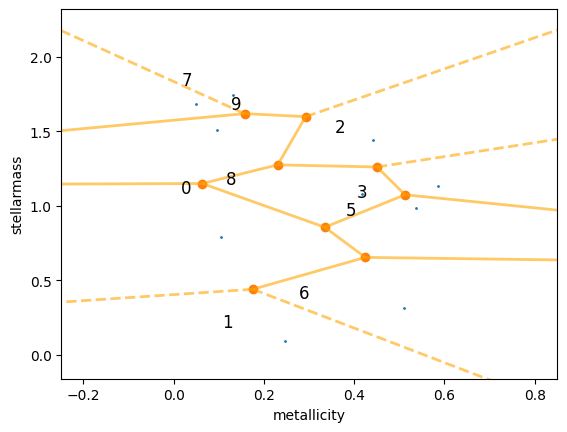

In [9]:
fig = voronoi_plot_2d(vor, show_vertices=True, line_colors='orange', line_width=2, line_alpha=0.6, point_size=2, show_points = True)
for label, (x, y) in groups.items():
    if label ==8:
        y-=.25
    if label ==3:
        x+=.25
    plt.text(x, y, label, fontsize=12, ha='right', va='bottom')
plt.xlabel('metallicity')
plt.ylabel('stellarmass')
xvals = [x[0] for x in modified_tuples2]
yvals = [x[1] for x in modified_tuples2]
plt.xlim(min(xvals)-.25, max(xvals)+.25)
plt.ylim(min(yvals)-.25, max(yvals)+.25)
plt.show()

In [ ]:
itemset, rules = apriori(transactions=modified_tuples2, min_support= 2/len(modified_tuples2), min_confidence=.5, bins = 10)

In [ ]:
filtered_rules = []
#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in rules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum_dict(lhs_items)
    rhs_plnum = get_plnum_dict(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum_dict(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)
rules = filtered_rules.copy()

In [10]:
print(rules.__len__())
for rule in rules:
    print(rule)

60
{group 0: F Warm Mini-Neptune Short Orbital1} -> {group 0: F Hot Terrestrial Short Orbital1} (conf: 0.500, supp: 0.002, lift: 38.450, conv: 1.974)
{group 0: G Warm Mini-Neptune Medium-Long Orbital1} -> {group 0: G Hot Mini-Neptune Short Orbital1} (conf: 1.000, supp: 0.002, lift: 20.784, conv: 951885565.670)
{group 1: M Cold Sub-Saturn Medium-Long Orbital1} -> {group 1: M Warm Mini-Neptune Short Orbital1} (conf: 0.667, supp: 0.001, lift: 146.476, conv: 2.986)
{group 1: M Temperate Mini-Neptune Short Orbital1} -> {group 1: M Warm Terrestrial Short Orbital1} (conf: 0.500, supp: 0.001, lift: 69.909, conv: 1.986)
{group 1: M Temperate Terrestrial Short Orbital1} -> {group 1: M Warm Terrestrial Short Orbital1} (conf: 0.500, supp: 0.001, lift: 69.909, conv: 1.986)
{group 2: F Temperate Gas Giant Medium-Long Orbital1} -> {group 2: F Cold Gas Giant Long Orbital1} (conf: 1.000, supp: 0.001, lift: 769.000, conv: 998699609.883)
{group 2: F Cold Gas Giant Long Orbital1} -> {group 2: F Temperate 

### Testing Significant Support

In [ ]:
from minsupport import estimate_s_min
f = {}
t = len(modified_tuples)
for transaction in modified_tuples:
    for item in transaction[1:]:
        if item in f:
            f[item]+=1
        else:
            f[item] = 1
for item in f:
    f[item]/=t

In [ ]:
print(estimate_s_min(modified_tuples, 3, f=f))

# Testing binning efficiency

In [ ]:
from scipy import stats
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d, cKDTree
from scipy.cluster.hierarchy import fclusterdata
from collections import defaultdict
import math

In [ ]:
#equal width binning
'''def dividebins(bins, transactions, training_data):
    first_numbers = [t[0] for t in transactions]
    train = [t[0] for t in training_data]
    min_val, max_val = min(first_numbers), max(first_numbers)
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    result = {}
    for i in range(bins):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        key = f'{lo:.4f}<=x<={hi:.4f}'
        result[key] = [0,0]
    for t in transactions:
        num = t[0]
        for i in range(bins):
            lo = bin_edges[i]
            hi = bin_edges[i + 1]
            if (lo <= num <= hi) if i == bins - 1 else (lo <= num < hi):
                key = f'{lo:.4f}<=x<={hi:.4f}'
                result[key][0]+=1
                break
    for t in train:
        for i in range(bins):
            lo = bin_edges[i]
            hi = bin_edges[i + 1]
            if (lo <= t <= hi) if i == bins - 1 else (lo <= t < hi):
                key = f'{lo:.4f}<=x<={hi:.4f}'
                result[key][1]+=1
                break
    return result, #bin_edges'''

#Equal frequency binning
'''def dividebins(bins, transactions, training_data):
    if not transactions or bins <= 0:
        return {}
    sorted_transactions = sorted(transactions, key=lambda x: x[0])
    sort_training = [x[0] for x in training_data]
    n = len(transactions)
    size = n // bins
    remainder = n % bins
    result = {}
    start_idx = 0
    bin_edges = []
    for i in range(bins):
        bin_size = size + (1 if i < remainder else 0)
        end_idx = start_idx + bin_size
        bin_slice = sorted_transactions[start_idx:end_idx]
        if bin_slice:
            lo = bin_slice[0][0]
            hi = bin_slice[-1][0]
        else:
            lo = hi = None
        key = f'{lo:.4f}<=x<={hi:.4f}' if lo is not None else f'empty_bin_{i}'
        bin_edges.append(lo)
        train = 0
        for trainvalue in sort_training:
            if trainvalue>lo and trainvalue<=hi:
                train+=1
        result[key] = [sum(1 for t in bin_slice), train]

        start_idx = end_idx
    bin_edges.append(hi)
    return result#, bin_edges'''

#Kmean binning
def dividebins(bins, transactions, training_data):
    transactionsvalues = [[x[0]] for x in transactions]
    train = [x[0] for x in training_data]
    transactionsvalues = list(map(tuple, transactionsvalues))
    kmeans = KMeans(n_clusters=bins)
    kmeans.fit(transactionsvalues)
    first_numbers = [t[0] for t in transactions]
    min_val, max_val = min(first_numbers), max(first_numbers)
    binedge = [min_val]
    for i in range(kmeans.cluster_centers_.__len__()-1):
        low = kmeans.cluster_centers_[i-1]
        high = kmeans.cluster_centers_[i]
        middle = float(((high + low)/2)[0])
        binedge.append(middle)
    binedge.append(max_val)
    binedge = sorted(binedge)
    result = {}
    for i in range(bins):
        lo = binedge[i]
        hi = binedge[i + 1]
        key = f'{lo:.4f}<=x<={hi:.4f}'
        result[key] = [0,0]
    for t in transactions:
        num = t[0]
        for i in range(bins):
            lo = binedge[i]
            hi = binedge[i + 1]
            if (lo <= num <= hi) if i == bins - 1 else (lo <= num < hi):
                key = f'{lo:.4f}<=x<={hi:.4f}'
                result[key][0]+=1
                break
    for t in train:
        for i in range(bins):
            lo = binedge[i]
            hi = binedge[i + 1]
            if (lo <= t <= hi) if i == bins - 1 else (lo <= t < hi):
                key = f'{lo:.4f}<=x<={hi:.4f}'
                result[key][1]+=1
                break
    return result, binedge

#kmeans with two values
'''def dividebins(bins, transactions, training_data):
    values = np.array([[x[0], x[1]] for x in transactions])
    train = np.array([[x[0], x[1]] for x in training_data])
    kmeans = KMeans(n_clusters=bins, random_state=0)
    labels = kmeans.fit_predict(values)
    trainlabels = kmeans.predict(train)
    result = defaultdict(list)
    for i, transaction in enumerate(transactions):
        if f"group {labels[i]}" in result:
            result[f"group {labels[i]}"][0]+=1
        else:
            result[f"group {labels[i]}"]= [1,0]
    for i, transaction in enumerate(training_data):
        result[f"group {trainlabels[i]}"][1]+=1
    return dict(result)'''

#voronoi binning
'''def dividebins(bins, transactions, training_data):
    xvals = [x[0] for x in transactions]
    yvals = [x[1] for x in transactions]
    xlow, xhigh = min(xvals), max(xvals)
    ylow, yhigh = min(yvals), max(yvals)
    points = np.array([[np.random.uniform(xlow, xhigh), np.random.uniform(ylow, yhigh)] for i in range(bins)])
    tree = cKDTree(points)
    assignments = {}
    distances, indices = tree.query([[x[0], x[1]] for x in transactions])
    distrain, trainindices = tree.query([[x[0], x[1]] for x in training_data])
    for idx, transaction in enumerate(transactions):
        string = 'group ' + str(indices[idx])
        if string not in assignments:
            assignments[string] = [0,0]
        assignments[string][0]+=1
    for idx, transaction in enumerate(training_data):
        string = 'group ' + str(trainindices[idx])
        if string not in assignments:
            assignments[string] = [0,0]
        assignments[string][1]+=1
    return assignments'''

### Incorporating Chi-Squared tests

In [ ]:
trainset = random.sample(modified_tuples2, k=round(len(modified_tuples2) * .7))
a = dividebins(bins=10, transactions=modified_tuples2, training_data=trainset)
print(a)

In [ ]:
observed = [a[x][1] for x in a]
expected = [a[x][0] for x in a]
for i in reversed(range(0,len(expected))):
    if expected[i]<5:
        del(expected[i])
        del(observed[i])
sumexp = sum(expected)
for i in range(len(expected)):
    expected[i] = expected[i]*(sum(observed)/sumexp)
print('expected counts: ', expected)
print(f'observed counts:  {observed}')
print(f'fit: {sum(observed)/sum(expected)} (should be about 1)')
chi2_statistic, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-squared statistic: {chi2_statistic}")
print(f"P-value: {p_value}")
alpha = 0.05
if p_value <= alpha:
    print("Reject the null hypothesis: The observed distribution is significantly different from the expected distribution.")
else:
    print("Fail to reject the null hypothesis: The observed distribution does not significantly differ from the expected distribution.")

### Incorperating PSI into the analysis

In [ ]:
# PSI is useful when comparing distributions with a large number of bins. This doesn't really work in my case if bins==10. It works when bins == 30 though.
'''
PSI<0.1 indicates there are no significant population changes
0.1≤PSI<0.25 suggests moderate changes in the distribution
PSI≥0.25 suggests significant changes in distribution

the proportion of the reference data in category c
Rc = (the number of reference data points with category c) / (the number of reference data points)
Mc= (the number of monitored data points with category c) / (the number of monitored data points)

PSI = sum((Rc-Mc)*ln(Mc/Rc))
'''
trainset = random.sample(modified_tuples2, k=round(len(modified_tuples2) * .7))
a = dividebins(bins=30, transactions=modified_tuples2, training_data=trainset)
print('dataset: ', a)
observed = [a[x][1] for x in a]
expected = [a[x][0] for x in a]
sumexp = sum(expected)
sumobs = sum(observed)
psi = 0
for i in range(len(expected)):
    Mc = expected[i]/sumexp
    Rc = observed[i]/sumobs
    if Mc == 0:
        Mc = .001
    if Rc == 0:
        Rc = .001
    psi+= (Mc-Rc)*(np.log(Mc/Rc))
if psi<.1:
    print(f'PSI = {psi}, this indicates that there are no significant population differences.')
elif .1<=psi<=.25:
    print(f'PSI = {psi}, this indicates that there are moderate population differences.')
else:
    print(f'PSI = {psi}, this indicates that there are significant population differences.')

### Looking at average change in bin interval

In [ ]:
trainset = random.sample(modified_tuples, k=round(len(modified_tuples) * .7))
a, edges = dividebins(bins=10, transactions=modified_tuples, training_data=trainset)
b, trainedges = dividebins(bins=10, transactions=trainset, training_data=trainset)
print(edges)
print(trainedges)
avgdistance = 0
for i in range(len(edges)):
    avgdistance += max(edges[i], trainedges[i]) - min(edges[i], trainedges[i])
avgdistance /= len(edges)

print(f'the average distance between the edge of the population and the sample is {avgdistance}')

### Getting graphs out of the above qualities

In [ ]:
import seaborn as sns

In [ ]:
x = []
y = []
good = []
for numberofbins in range(1, 14):
    for j in range(3):
        trainset = random.sample(modified_tuples, k=round(len(modified_tuples) * .7))
        binnumber = numberofbins*5
        a = dividebins(bins=binnumber, transactions=modified_tuples, training_data=trainset)
        observed = [a[x][1] for x in a]
        expected = [a[x][0] for x in a]
        for i in reversed(range(0,len(expected))):
            if expected[i]<5:
                del(expected[i])
                del(observed[i])
        sumexp = sum(expected)
        for i in range(len(expected)):
            expected[i] = expected[i]*(sum(observed)/sumexp)
        chi2_statistic, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
        alpha = 0.05
        if p_value <= alpha:
            good.append(False)
        else:
            good.append(True)
        x.append(binnumber)
        y.append(p_value)
scatter = sns.scatterplot(x = x, y=y, hue = good, hue_order= [True, False])
scatter.set( xlabel = 'number of bins' , ylabel='p-value', title='p-value from Goodness of Fit Test: equal frequency')

In [ ]:
x = []
y = []
good = []
for numberofbins in range(1, 14):
    for j in range(3):
        trainset = random.sample(modified_tuples, k=round(len(modified_tuples) * .7))
        binnumber = numberofbins*5
        x.append(binnumber)
        a = dividebins(bins=binnumber, transactions=modified_tuples, training_data=trainset)
        observed = [a[x][1] for x in a]
        expected = [a[x][0] for x in a]
        sumexp = sum(expected)
        sumobs = sum(observed)
        psi = 0
        for i in range(len(expected)):
            Mc = expected[i]/sumexp
            Rc = observed[i]/sumobs
            if Mc == 0:
                Mc = .001
            if Rc == 0:
                Rc = .001
            psi+= (Mc-Rc)*(np.log(Mc/Rc))
        y.append(psi)
        if psi<.1:
            good.append('good')
        elif .1<=psi<=.25:
            good.append('okay')
        else:
            good.append('bad')
scatter = sns.scatterplot(x = x, y=y, hue = good, hue_order= ['good', 'okay', 'bad'])
scatter.set( xlabel = 'number of bins' , ylabel='psi', title='Population Stability Index (PSI): kmeans (one variable)')

In [ ]:
x = []
y = []
for numberofbins in range(1, 50):
    for j in range(3):
        trainset = random.sample(modified_tuples, k=round(len(modified_tuples) * .7))
        binnumber = numberofbins*5
        x.append(binnumber)
        a, edges = dividebins(bins=binnumber, transactions=modified_tuples, training_data=trainset)
        b, trainedges = dividebins(bins=binnumber, transactions=trainset, training_data=trainset)
        avgdistance = 0
        for i in range(len(edges)):
            avgdistance += max(edges[i], trainedges[i]) - min(edges[i], trainedges[i])
        avgdistance /= len(edges)
        y.append(avgdistance)

scatter = sns.scatterplot(x = x, y=y)
scatter.set( xlabel = 'number of bins' , ylabel='Stellar Metallicity', title='average change in bin edge between population and sample: kmeans')

In [ ]:
itemset, rules = apriori(transactions = modified_tuples, min_support=2/len(modified_tuples), min_confidence=.5, bins=3)

In [8]:
filtered_rules = []
#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in rules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum(lhs_items)
    rhs_plnum = get_plnum(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)
rules = filtered_rules.copy()

In [ ]:
len(filtered_rules)
filtered_rules